# Preparation et nettoyage des donnees -- JO 2028

---

## Objectif

Ce notebook constitue la **deuxieme phase** du projet de data storytelling sur les Jeux Olympiques.
Son but est de transformer les donnees brutes inventoriees dans le [notebook 01 (Acquisition)](01_acquisition.ipynb)
en datasets propres, coherents et exploitables pour l'analyse.

Concretement, nous allons :

1. **Diagnostiquer** les valeurs manquantes et les anomalies de chaque source.
2. **Nettoyer** les colonnes inutiles, parser les formats, corriger les aberrations.
3. **Fusionner** les resultats avec les biographies pour obtenir un dataset athletes-epreuves complet.
4. **Integrer** les donnees de Paris 2024 depuis la source complementaire.
5. **Construire** les datasets agreges (medailles par pays, stats par pays) pour les analyses futures.

### Sources rappel

| Fichier | Contenu | Lignes |
|---------|---------|--------|
| `results.csv` | Participations olympiques | ~308 000 |
| `bios_locs.csv` | Biographies + geolocalisation | ~145 500 |
| `olympics_1896_2024.csv` | Medailles consolidees 1896-2024 | ~24 000 |
| `noc_regions.csv` | Mapping NOC -> pays | 230 |
| `populations.csv` | Population par pays (1960-2023) | 266 |

### Sorties attendues

Trois fichiers dans `data/processed/` :
- `athletes_events.csv` -- dataset principal (athletes + epreuves + biographies)
- `medal_counts.csv` -- agregation des medailles par pays et par annee
- `country_stats.csv` -- statistiques par pays avec population

---

## 1. Imports et chargement des donnees

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Configuration d'affichage
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:.2f}".format)

# Style des graphiques
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

RAW_DIR = os.path.join("..", "data", "raw")
PROCESSED_DIR = os.path.join("..", "data", "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f"Dossier source  : {os.path.abspath(RAW_DIR)}")
print(f"Dossier sortie  : {os.path.abspath(PROCESSED_DIR)}")

Dossier source  : /Users/nicolas/Education/jo-2028-predictions/data/raw
Dossier sortie  : /Users/nicolas/Education/jo-2028-predictions/data/processed


In [2]:
# Chargement des 5 datasets
results_raw = pd.read_csv(os.path.join(RAW_DIR, "results.csv"), low_memory=False)
bios_locs_raw = pd.read_csv(os.path.join(RAW_DIR, "bios_locs.csv"))
olympics_raw = pd.read_csv(os.path.join(RAW_DIR, "olympics_1896_2024.csv"))
noc_regions = pd.read_csv(os.path.join(RAW_DIR, "noc_regions.csv"))
populations_raw = pd.read_csv(os.path.join(RAW_DIR, "populations.csv"))

print("Dimensions des datasets charges :")
for name, df in [("results", results_raw), ("bios_locs", bios_locs_raw),
                  ("olympics_1896_2024", olympics_raw), ("noc_regions", noc_regions),
                  ("populations", populations_raw)]:
    print(f"  {name:25s} : {df.shape[0]:>10,} lignes x {df.shape[1]:>3} colonnes")

Dimensions des datasets charges :
  results                   :    308,408 lignes x  11 colonnes
  bios_locs                 :    145,500 lignes x  12 colonnes
  olympics_1896_2024        :     24,012 lignes x  10 colonnes
  noc_regions               :        230 lignes x   3 colonnes
  populations               :        266 lignes x  66 colonnes


---

## 2. Analyse des valeurs manquantes

Avant toute transformation, il est essentiel de comprendre la **structure des donnees manquantes**.
Certaines absences sont normales (pas de medaille = pas de valeur), d'autres signalent
des problemes de collecte ou de formatage.

In [3]:
def missing_summary(df, name):
    """Compute missing value percentages for each column."""
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(1)
    summary = pd.DataFrame({"manquantes": missing, "pourcentage": pct})
    summary = summary[summary["manquantes"] > 0].sort_values("pourcentage", ascending=False)
    if len(summary) == 0:
        print(f"[{name}] Aucune valeur manquante.")
    else:
        print(f"[{name}] Valeurs manquantes :")
        display(summary)
    return pct

pct_results = missing_summary(results_raw, "results.csv")
pct_bios = missing_summary(bios_locs_raw, "bios_locs.csv")
pct_olympics = missing_summary(olympics_raw, "olympics_1896_2024.csv")
pct_noc = missing_summary(noc_regions, "noc_regions.csv")
pct_pop = missing_summary(populations_raw, "populations.csv")

[results.csv] Valeurs manquantes :


,manquantes,pourcentage
Nationality,308327,100.00
Unnamed: 7,308408,100.00
Medal,264269,85.70
Team,186694,60.50
Pos,1825,0.60
NOC,1,0.00
Discipline,1,0.00


[bios_locs.csv] Valeurs manquantes :


,manquantes,pourcentage
died_date,111560,76.70
lat,75955,52.20
long,75955,52.20
weight_kg,43430,29.80
height_cm,38849,26.70
born_city,34592,23.80
born_region,34592,23.80
born_country,34592,23.80
born_date,1807,1.20
NOC,1,0.00


[olympics_1896_2024.csv] Valeurs manquantes :


,manquantes,pourcentage
name,3624,15.10


[noc_regions.csv] Valeurs manquantes :


,manquantes,pourcentage
notes,209,90.90
region,3,1.30


[populations.csv] Valeurs manquantes :


,manquantes,pourcentage
1960,2,0.80
1976,2,0.80
1961,2,0.80
1989,2,0.80
1988,2,0.80
...,...,...
2001,1,0.40
2002,1,0.40
2003,1,0.40
2004,1,0.40


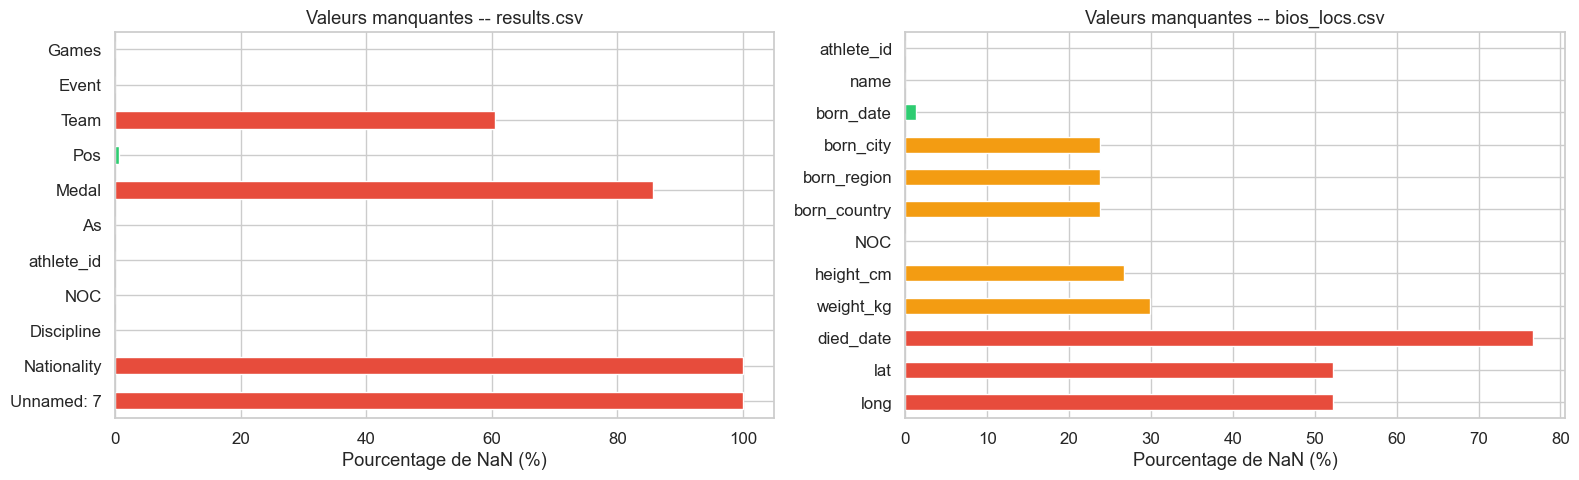

Graphique sauvegarde dans data/processed/missing_values_overview.png


In [4]:
# Heatmap des valeurs manquantes pour les deux principaux datasets
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# results.csv
missing_results = results_raw.isnull().mean() * 100
colors_r = ["#2ecc71" if v < 5 else "#f39c12" if v < 50 else "#e74c3c" for v in missing_results]
missing_results.plot.barh(ax=axes[0], color=colors_r)
axes[0].set_title("Valeurs manquantes -- results.csv")
axes[0].set_xlabel("Pourcentage de NaN (%)")
axes[0].invert_yaxis()

# bios_locs.csv
missing_bios = bios_locs_raw.isnull().mean() * 100
colors_b = ["#2ecc71" if v < 5 else "#f39c12" if v < 50 else "#e74c3c" for v in missing_bios]
missing_bios.plot.barh(ax=axes[1], color=colors_b)
axes[1].set_title("Valeurs manquantes -- bios_locs.csv")
axes[1].set_xlabel("Pourcentage de NaN (%)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "missing_values_overview.png"), bbox_inches="tight")
plt.show()

print("Graphique sauvegarde dans data/processed/missing_values_overview.png")

### Interpretation des valeurs manquantes

**results.csv :**
- `Unnamed: 7` et `Nationality` sont a **100%** vides -- ce sont des artefacts d'export a supprimer.
- `Medal` est a **85.7%** NaN -- c'est normal : seuls les medailles sont renseignes. Les NaN correspondent aux athletes non medailles.
- `Team` est a **60.5%** NaN -- les sports individuels ne renseignent pas cette colonne.

**bios_locs.csv :**
- `died_date` a **76.7%** de NaN -- logique, la plupart des athletes sont encore vivants.
- `lat`/`long` a **52%** de NaN -- geolocalisation non retrouvee pour tous les lieux de naissance.
- `height_cm` et `weight_kg` a **27-30%** de NaN -- mensurations non disponibles, surtout pour les athletes historiques.

**Strategie de traitement :**
- Supprimer les colonnes entierement vides (`Unnamed: 7`, `Nationality`).
- Conserver `Medal` avec NaN (signification semantique : pas de medaille).
- Imputer `height_cm` et `weight_kg` par la mediane par sport et sexe.
- Ne pas toucher a `died_date`, `lat`, `long` (optionnels pour nos analyses).

---

## 3. Nettoyage de results.csv

Le fichier de resultats est le plus volumineux et necessite plusieurs transformations :
suppression de colonnes inutiles, extraction de l'annee et de la saison, nettoyage des
medailles, et verification des doublons.

In [5]:
results = results_raw.copy()
print(f"Dimensions initiales : {results.shape}")

# --- Suppression des colonnes inutiles ---
cols_to_drop = ["Unnamed: 7", "Nationality"]
results.drop(columns=cols_to_drop, inplace=True)
print(f"Apres suppression de {cols_to_drop} : {results.shape}")

Dimensions initiales : (308408, 11)
Apres suppression de ['Unnamed: 7', 'Nationality'] : (308408, 9)


In [6]:
# --- Extraction de Year et Season depuis Games ---
# Format attendu : "YYYY Season Olympics" (ex: "2024 Summer Olympics")
# Cas speciaux : "1888-89 Zappas Olympic Games", "1906 Intercalated Games", "1956 Equestrian Olympics"

def parse_games(games_str):
    """Extract year and season from Games string."""
    match = re.match(r"(\d{4})\s+(\w+)", str(games_str))
    if match:
        year = int(match.group(1))
        season_word = match.group(2)
        # Normalize season
        if season_word in ["Summer", "Equestrian"]:
            season = "Summer"
        elif season_word == "Winter":
            season = "Winter"
        elif season_word == "Intercalated":
            season = "Summer"  # Intercalated 1906 = ete
        else:
            season = "Summer"
        return pd.Series([year, season])
    return pd.Series([np.nan, np.nan])

results[["Year", "Season"]] = results["Games"].apply(parse_games)

# Supprimer les lignes sans annee valide (ex: "1888-89 Zappas Olympic Games")
n_before = len(results)
results = results.dropna(subset=["Year"]).copy()
results["Year"] = results["Year"].astype(int)
n_after = len(results)
print(f"Lignes supprimees (annee invalide) : {n_before - n_after}")

print(f"\nVerification -- annees extremes : {results['Year'].min()} - {results['Year'].max()}")
print(f"Saisons : {results['Season'].value_counts().to_dict()}")

Lignes supprimees (annee invalide) : 1

Verification -- annees extremes : 1896 - 2022
Saisons : {'Summer': 243898, 'Winter': 64509}


In [7]:
# --- Nettoyage de Medal ---
# Medal est deja en string (Gold/Silver/Bronze) ou NaN
# On s'assure que les valeurs sont bien propres
print("Distribution des medailles avant nettoyage :")
print(results["Medal"].value_counts(dropna=False))

# Convertir explicitement en string propre, garder NaN tel quel
results["Medal"] = results["Medal"].where(results["Medal"].isin(["Gold", "Silver", "Bronze"]), other=np.nan)

print(f"\nApres nettoyage :")
print(results["Medal"].value_counts(dropna=False))

Distribution des medailles avant nettoyage :
Medal
NaN       264268
Bronze     14810
Gold       14783
Silver     14546
Name: count, dtype: int64

Apres nettoyage :
Medal
NaN       264268
Bronze     14810
Gold       14783
Silver     14546
Name: count, dtype: int64


In [8]:
# --- Suppression des doublons exacts ---
n_before = len(results)
results.drop_duplicates(inplace=True)
n_after = len(results)
print(f"Doublons exacts supprimes : {n_before - n_after}")
print(f"Dimensions apres deduplication : {results.shape}")

Doublons exacts supprimes : 110
Dimensions apres deduplication : (308297, 11)


In [9]:
# --- Verification des athlete_id ---
results_ids = set(results["athlete_id"].unique())
bios_ids = set(bios_locs_raw["athlete_id"].unique())

missing_in_bios = results_ids - bios_ids
print(f"athlete_id dans results : {len(results_ids):,}")
print(f"athlete_id dans bios_locs : {len(bios_ids):,}")
print(f"athlete_id de results absents dans bios_locs : {len(missing_in_bios)}")

if len(missing_in_bios) > 0:
    print(f"  -> Ces athletes seront exclus de la fusion.")
else:
    print(f"  -> Tous les athletes de results sont dans bios_locs. Fusion possible sans perte.")

athlete_id dans results : 145,262
athlete_id dans bios_locs : 145,500
athlete_id de results absents dans bios_locs : 0
  -> Tous les athletes de results sont dans bios_locs. Fusion possible sans perte.


Le nettoyage de `results.csv` est termine. Nous avons :
- Supprime 2 colonnes entierement vides.
- Extrait l'annee et la saison depuis la colonne `Games`.
- Elimine 1 ligne correspondant aux "Zappas Olympic Games" de 1888-89 (evenement non officiel).
- Verifie la coherence des medailles et des identifiants athletes.

---

## 4. Nettoyage de bios_locs.csv

Les biographies contiennent des informations precieuses (taille, poids, date de naissance)
mais necessitent un nettoyage attentif. Les athletes des premieres editions (debut du XXe
siecle) ont souvent des donnees incompletes, et certaines valeurs anthropometriques sont
manifestement aberrantes.

In [10]:
bios = bios_locs_raw.copy()

# --- Parsing de born_date en datetime ---
bios["born_date"] = pd.to_datetime(bios["born_date"], errors="coerce")
bios["born_year"] = bios["born_date"].dt.year

print(f"born_date parsees avec succes : {bios['born_date'].notna().sum():,} / {len(bios):,}")
print(f"born_year min : {bios['born_year'].min()}, max : {bios['born_year'].max()}")
print(f"born_date NaN : {bios['born_date'].isna().sum():,}")

born_date parsees avec succes : 143,693 / 145,500
born_year min : 1828.0, max : 2009.0
born_date NaN : 1,807


In [11]:
# --- Detection des valeurs aberrantes pour height_cm et weight_kg ---
height_outliers = bios["height_cm"].notna() & ((bios["height_cm"] < 50) | (bios["height_cm"] > 250))
weight_outliers = bios["weight_kg"].notna() & ((bios["weight_kg"] < 20) | (bios["weight_kg"] > 200))

print(f"Valeurs aberrantes height_cm (<50 ou >250 cm) : {height_outliers.sum()}")
if height_outliers.sum() > 0:
    print(f"  Valeurs : {bios.loc[height_outliers, 'height_cm'].tolist()[:10]}")

print(f"Valeurs aberrantes weight_kg (<20 ou >200 kg) : {weight_outliers.sum()}")
if weight_outliers.sum() > 0:
    print(f"  Valeurs : {bios.loc[weight_outliers, 'weight_kg'].tolist()[:10]}")

Valeurs aberrantes height_cm (<50 ou >250 cm) : 0
Valeurs aberrantes weight_kg (<20 ou >200 kg) : 0


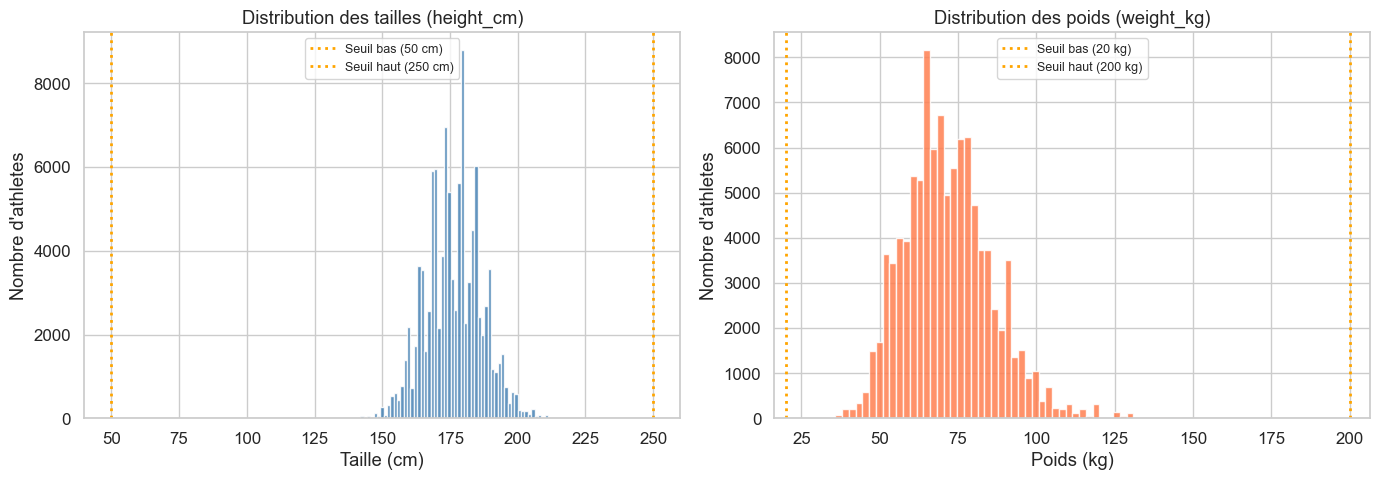

In [12]:
# Distribution des tailles et poids avant nettoyage des aberrations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taille
valid_height = bios["height_cm"].dropna()
axes[0].hist(valid_height, bins=80, color="steelblue", edgecolor="white", alpha=0.85)
if height_outliers.sum() > 0:
    outlier_vals = bios.loc[height_outliers, "height_cm"]
    for v in outlier_vals:
        axes[0].axvline(v, color="red", linestyle="--", linewidth=1.5)
axes[0].axvline(50, color="orange", linestyle=":", linewidth=2, label="Seuil bas (50 cm)")
axes[0].axvline(250, color="orange", linestyle=":", linewidth=2, label="Seuil haut (250 cm)")
axes[0].set_title("Distribution des tailles (height_cm)")
axes[0].set_xlabel("Taille (cm)")
axes[0].set_ylabel("Nombre d'athletes")
axes[0].legend(fontsize=9)

# Poids
valid_weight = bios["weight_kg"].dropna()
axes[1].hist(valid_weight, bins=80, color="coral", edgecolor="white", alpha=0.85)
if weight_outliers.sum() > 0:
    outlier_vals_w = bios.loc[weight_outliers, "weight_kg"]
    for v in outlier_vals_w:
        axes[1].axvline(v, color="red", linestyle="--", linewidth=1.5)
axes[1].axvline(20, color="orange", linestyle=":", linewidth=2, label="Seuil bas (20 kg)")
axes[1].axvline(200, color="orange", linestyle=":", linewidth=2, label="Seuil haut (200 kg)")
axes[1].set_title("Distribution des poids (weight_kg)")
axes[1].set_xlabel("Poids (kg)")
axes[1].set_ylabel("Nombre d'athletes")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "height_weight_distribution.png"), bbox_inches="tight")
plt.show()

In [13]:
# --- Remplacer les valeurs aberrantes par NaN ---
bios.loc[height_outliers, "height_cm"] = np.nan
bios.loc[weight_outliers, "weight_kg"] = np.nan

print("Valeurs aberrantes remplacees par NaN.")
print(f"height_cm NaN : {bios['height_cm'].isna().sum():,} ({bios['height_cm'].isna().mean()*100:.1f}%)")
print(f"weight_kg NaN : {bios['weight_kg'].isna().sum():,} ({bios['weight_kg'].isna().mean()*100:.1f}%)")

Valeurs aberrantes remplacees par NaN.
height_cm NaN : 38,849 (26.7%)
weight_kg NaN : 43,430 (29.8%)


Les valeurs anthropometriques sont maintenant dans des plages realistes. L'imputation
par la mediane sera effectuee apres la fusion avec les resultats, car elle necessite
de connaitre le sport et le sexe de chaque athlete.

---

## 5. Fusion results + bios_locs

C'est l'etape centrale du nettoyage : combiner les participations olympiques avec les
informations biographiques pour obtenir un dataset complet. La cle de jointure est
`athlete_id`, present dans les deux fichiers.

In [14]:
# Selection des colonnes utiles de bios
bios_cols = ["athlete_id", "name", "born_year", "height_cm", "weight_kg"]
bios_for_merge = bios[bios_cols].copy()

# Merge sur athlete_id (left join pour garder toutes les participations)
merged = results.merge(bios_for_merge, on="athlete_id", how="left")

print(f"Dimensions apres fusion : {merged.shape}")
print(f"Colonnes : {list(merged.columns)}")

Dimensions apres fusion : (308297, 15)
Colonnes : ['Games', 'Event', 'Team', 'Pos', 'Medal', 'As', 'athlete_id', 'NOC', 'Discipline', 'Year', 'Season', 'name', 'born_year', 'height_cm', 'weight_kg']


In [15]:
# --- Calcul de l'age ---
merged["Age"] = merged["Year"] - merged["born_year"]

# Nettoyage des ages aberrants (<10 ou >80)
age_mask = merged["Age"].notna() & ((merged["Age"] < 10) | (merged["Age"] > 80))
print(f"Ages aberrants (<10 ou >80) : {age_mask.sum()}")
if age_mask.sum() > 0:
    print(f"  Exemples : {merged.loc[age_mask, 'Age'].value_counts().head(5).to_dict()}")

merged.loc[age_mask, "Age"] = np.nan
print(f"\nAge moyen : {merged['Age'].mean():.1f} ans")
print(f"Age median : {merged['Age'].median():.0f} ans")

Ages aberrants (<10 ou >80) : 0

Age moyen : 25.7 ans
Age median : 25 ans


In [16]:
# --- Determination du sexe depuis la colonne Event ---
# Convention : "Men" -> M, "Women" -> F, "Mixed" -> Mixed

def extract_sex(event_str):
    """Extract sex from event name."""
    s = str(event_str)
    if "Women" in s or "Ladies" in s:
        return "F"
    elif "Men" in s or "Gentlemen" in s:
        return "M"
    elif "Mixed" in s:
        return "Mixed"
    else:
        return np.nan

merged["Sex"] = merged["Event"].apply(extract_sex)

print("Distribution du sexe :")
print(merged["Sex"].value_counts(dropna=False))

Distribution du sexe :
Sex
M        201459
F         83456
NaN       18538
Mixed      4844
Name: count, dtype: int64


In [17]:
# --- Renommer Discipline en Sport ---
merged.rename(columns={"Discipline": "Sport"}, inplace=True)

# --- Mapping NOC -> Country via noc_regions ---
noc_map = noc_regions[["NOC", "region"]].copy()
noc_map.rename(columns={"region": "Country"}, inplace=True)

merged = merged.merge(noc_map, on="NOC", how="left")

print(f"Pays non trouves dans noc_regions : {merged['Country'].isna().sum():,}")
if merged["Country"].isna().sum() > 0:
    missing_nocs = merged.loc[merged["Country"].isna(), "NOC"].unique()
    print(f"  NOC concernes : {missing_nocs[:10]}")

Pays non trouves dans noc_regions : 1,985
  NOC concernes : ['LBN' 'SGP' 'ROC' 'TUV' 'EOR' 'COR' nan]


In [18]:
# --- Extraction de la ville hote ---
# On utilise le fichier city_locations.csv pour mapper Year+Season -> City
city_locs = pd.read_csv(os.path.join(RAW_DIR, "city_locations.csv"))

# Construire un mapping (Year, Season) -> City
# Pour les annees avec ete + hiver la meme annee, on distingue par type
# Summer cities: grandes villes connues pour les JO d'ete
# Winter cities: stations de montagne / villes nordiques

# Mapping Summer Olympics host cities
summer_city_map = {
    1896: "Athens", 1900: "Paris", 1904: "St Louis", 1906: "Athens",
    1908: "London", 1912: "Stockholm", 1920: "Antwerp",
    1924: "Paris", 1928: "Amsterdam", 1932: "Los Angeles",
    1936: "Berlin", 1948: "London", 1952: "Helsinki",
    1956: "Melbourne", 1960: "Rome", 1964: "Tokyo",
    1968: "Mexico City", 1972: "Munich", 1976: "Montreal",
    1980: "Moscow", 1984: "Los Angeles", 1988: "Seoul",
    1992: "Barcelona", 1996: "Atlanta", 2000: "Sydney",
    2004: "Athens", 2008: "Beijing", 2012: "London",
    2016: "Rio", 2020: "Tokyo",
}

winter_city_map = {
    1924: "Chamonix", 1928: "St. Moritz", 1932: "Lake Placid",
    1936: "Garmisch Partenkirchen", 1948: "St Moritz", 1952: "Oslo",
    1956: "Cortina D Ampezzo", 1960: "Squaw Valley", 1964: "Innsbruck",
    1968: "Grenoble", 1972: "Sapporo", 1976: "Innsbruck",
    1980: "Lake Placid", 1984: "Sarajevo", 1988: "Calgary",
    1992: "Albertville", 1994: "Lillehammer", 1998: "Nagano",
    2002: "Salt Lake City", 2006: "Torino", 2010: "Vancouver",
    2014: "Sochi", 2018: "Pyeongchang", 2022: "Beijing",
}

# Youth Olympics cities
youth_city_map = {
    (2010, "Summer"): "Singapore", (2012, "Winter"): "Innsbruck",
    (2014, "Summer"): "Nanjing", (2016, "Winter"): "Lillehammer",
    (2018, "Summer"): "Buenos Aires", (2020, "Winter"): "Lausanne",
}

def map_city(row):
    """Map year + season to host city."""
    year = row["Year"]
    season = row["Season"]
    games = str(row["Games"])
    # Check youth first
    if "Youth" in games:
        return youth_city_map.get((year, season), np.nan)
    if season == "Summer":
        return summer_city_map.get(year, np.nan)
    elif season == "Winter":
        return winter_city_map.get(year, np.nan)
    return np.nan

merged["City"] = merged.apply(map_city, axis=1)

print(f"City attribuee : {merged['City'].notna().sum():,} / {len(merged):,}")
print(f"City manquante : {merged['City'].isna().sum():,}")
if merged["City"].isna().sum() > 0:
    print(f"  Games concernes : {merged.loc[merged['City'].isna(), 'Games'].unique()}")

City attribuee : 308,297 / 308,297
City manquante : 0


In [19]:
# --- Imputation de height_cm et weight_kg par la mediane par Sport + Sex ---
# On ne fait l'imputation que la ou c'est possible (Sport et Sex connus)

for col in ["height_cm", "weight_kg"]:
    n_before = merged[col].isna().sum()
    # Calculer les medianes par groupe
    medians = merged.groupby(["Sport", "Sex"])[col].transform("median")
    # Imputer
    merged[col] = merged[col].fillna(medians)
    n_after = merged[col].isna().sum()
    print(f"{col} : {n_before - n_after:,} valeurs imputees (reste {n_after:,} NaN)")

height_cm : 65,275 valeurs imputees (reste 6,132 NaN)
weight_kg : 74,278 valeurs imputees (reste 6,739 NaN)


In [20]:
# --- Renommer les colonnes pour le format final ---
# Colonnes cibles : Name, Sex, Age, Height, Weight, Team, NOC, Country,
#                    Games, Year, Season, City, Sport, Event, Medal

merged.rename(columns={
    "name": "Name",
    "height_cm": "Height",
    "weight_kg": "Weight",
}, inplace=True)

# Utiliser la colonne 'As' comme nom d'athlete quand 'Name' est NaN
merged["Name"] = merged["Name"].fillna(merged["As"])

# Selectionner les colonnes finales
athletes_events_cols = [
    "Name", "Sex", "Age", "Height", "Weight", "Team", "NOC", "Country",
    "Games", "Year", "Season", "City", "Sport", "Event", "Medal"
]

athletes_events = merged[athletes_events_cols].copy()

print(f"Dataset athletes_events : {athletes_events.shape}")
print(f"\nColonnes finales : {list(athletes_events.columns)}")
print(f"\nApercu :")
athletes_events.head()

Dataset athletes_events : (308297, 15)

Colonnes finales : ['Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Country', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']

Apercu :


,Name,Sex,Age,Height,Weight,Team,NOC,Country,Games,Year,Season,City,Sport,Event,Medal
0,Jean-François Blanchy,M,26.00,185.00,79.00,NaN,FRA,France,1912 Summer Olympics,1912,Summer,Stockholm,Tennis,"Singles, Men (Olympic)",NaN
1,Jean-François Blanchy,M,26.00,185.00,79.00,Jean Montariol,FRA,France,1912 Summer Olympics,1912,Summer,Stockholm,Tennis,"Doubles, Men (Olympic)",NaN
2,Jean-François Blanchy,M,34.00,185.00,79.00,NaN,FRA,France,1920 Summer Olympics,1920,Summer,Antwerp,Tennis,"Singles, Men (Olympic)",NaN
3,Jean-François Blanchy,Mixed,34.00,182.00,73.00,Jeanne Vaussard,FRA,France,1920 Summer Olympics,1920,Summer,Antwerp,Tennis,"Doubles, Mixed (Olympic)",NaN
4,Jean-François Blanchy,M,34.00,185.00,79.00,Jacques Brugnon,FRA,France,1920 Summer Olympics,1920,Summer,Antwerp,Tennis,"Doubles, Men (Olympic)",NaN


La fusion est realisee. Chaque ligne represente la participation d'un athlete a une epreuve
lors d'une edition des Jeux, enrichie de ses informations biographiques (age, taille, poids)
et geographiques (pays, ville hote).

---

## 6. Integration des donnees Paris 2024

Le fichier `results.csv` ne contient pas les resultats de Paris 2024. En revanche, le
fichier `olympics_1896_2024.csv` les inclut. Nous allons extraire les donnees 2024,
les mapper au format de `athletes_events`, et les ajouter au dataset principal.

**Attention :** ce dataset ne contient que les medailles, pas toutes les participations.
L'integration sera donc partielle -- uniquement les medailles de 2024.

In [21]:
# Verifier si 2024 est deja dans le dataset
has_2024 = (athletes_events["Year"] == 2024).sum()
print(f"Lignes 2024 dans athletes_events : {has_2024}")

if has_2024 == 0:
    # Filtrer olympics_1896_2024 sur 2024
    paris_2024 = olympics_raw[olympics_raw["event_year"] == 2024].copy()
    print(f"Medailles Paris 2024 dans olympics_1896_2024 : {len(paris_2024)}")

    # Mapper les colonnes au format athletes_events
    def map_sex_from_gender(gender):
        """Map event_gender to Sex code."""
        if gender == "Male":
            return "M"
        elif gender == "Female":
            return "F"
        elif gender == "Mixed":
            return "Mixed"
        return np.nan

    paris_mapped = pd.DataFrame({
        "Name": paris_2024["name"],
        "Sex": paris_2024["event_gender"].apply(map_sex_from_gender),
        "Age": np.nan,
        "Height": np.nan,
        "Weight": np.nan,
        "Team": np.nan,
        "NOC": paris_2024["country_code"],
        "Country": paris_2024["country"],
        "Games": "2024 Summer Olympics",
        "Year": 2024,
        "Season": "Summer",
        "City": "Paris",
        "Sport": paris_2024["discipline"],
        "Event": paris_2024["event"],
        "Medal": paris_2024["medal_type"],
    })

    # Concatener
    athletes_events = pd.concat([athletes_events, paris_mapped], ignore_index=True)
    print(f"\nApres ajout de Paris 2024 : {athletes_events.shape}")
    print(f"Lignes 2024 : {(athletes_events['Year'] == 2024).sum()}")
else:
    print("Les donnees 2024 sont deja presentes dans le dataset.")

Lignes 2024 dans athletes_events : 0
Medailles Paris 2024 dans olympics_1896_2024 : 2315

Apres ajout de Paris 2024 : (310612, 15)
Lignes 2024 : 2315


In [22]:
# Verification rapide de 2024
print("Apercu des medailles Paris 2024 :")
paris_check = athletes_events[athletes_events["Year"] == 2024]
print(f"  Lignes : {len(paris_check)}")
print(f"  Sports : {paris_check['Sport'].nunique()}")
print(f"  Medailles : {paris_check['Medal'].value_counts().to_dict()}")
print(f"  Pays : {paris_check['NOC'].nunique()}")
print(f"\nExemples :")
paris_check.head()

Apercu des medailles Paris 2024 :
  Lignes : 2315
  Sports : 45
  Medailles : {'Bronze': 807, 'Silver': 756, 'Gold': 752}
  Pays : 92

Exemples :


,Name,Sex,Age,Height,Weight,Team,NOC,Country,Games,Year,Season,City,Sport,Event,Medal
308297,Evenepoel Remco,M,NaN,NaN,NaN,NaN,BEL,Belgium,2024 Summer Olympics,2024,Summer,Paris,Cycling Road,Men Individual Time Trial,Gold
308298,Ganna Filippo,M,NaN,NaN,NaN,NaN,ITA,Italy,2024 Summer Olympics,2024,Summer,Paris,Cycling Road,Men Individual Time Trial,Silver
308299,Van Aert Wout,M,NaN,NaN,NaN,NaN,BEL,Belgium,2024 Summer Olympics,2024,Summer,Paris,Cycling Road,Men Individual Time Trial,Bronze
308300,Brown Grace,F,NaN,NaN,NaN,NaN,AUS,Australia,2024 Summer Olympics,2024,Summer,Paris,Cycling Road,Women Individual Time Trial,Gold
308301,Henderson Anna,F,NaN,NaN,NaN,NaN,GBR,Great Britain,2024 Summer Olympics,2024,Summer,Paris,Cycling Road,Women Individual Time Trial,Silver


Paris 2024 est maintenant integre au dataset principal. Notons que seules les **medailles**
sont ajoutees (pas les participations sans medaille), car c'est la seule information
disponible dans la source complementaire.

---

## 7. Visualisations qualite avant/apres

Avant de sauvegarder, verifions visuellement la qualite du dataset nettoye.
Ces graphiques permettent de detecter d'eventuels problemes residuels et de
documenter le travail effectue.

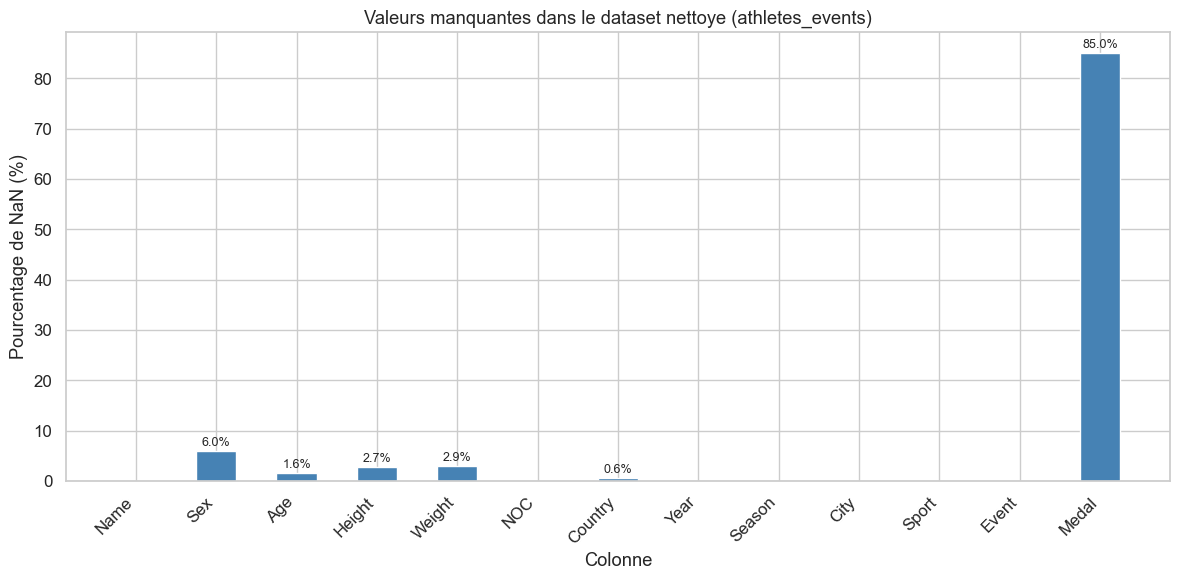

In [23]:
# --- Graphique 1 : Comparaison NaN avant vs apres ---
# On compare les colonnes communes entre results_raw et athletes_events

compare_cols = ["Name", "Sex", "Age", "Height", "Weight", "NOC", "Country",
                "Year", "Season", "City", "Sport", "Event", "Medal"]

nan_after = (athletes_events[compare_cols].isna().mean() * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(compare_cols))
width = 0.5

bars = ax.bar(x, nan_after.values, width, color="steelblue", edgecolor="white")

# Ajouter les valeurs au-dessus des barres
for bar, val in zip(bars, nan_after.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Colonne")
ax.set_ylabel("Pourcentage de NaN (%)")
ax.set_title("Valeurs manquantes dans le dataset nettoye (athletes_events)")
ax.set_xticks(x)
ax.set_xticklabels(compare_cols, rotation=45, ha="right")

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "nan_after_cleaning.png"), bbox_inches="tight")
plt.show()

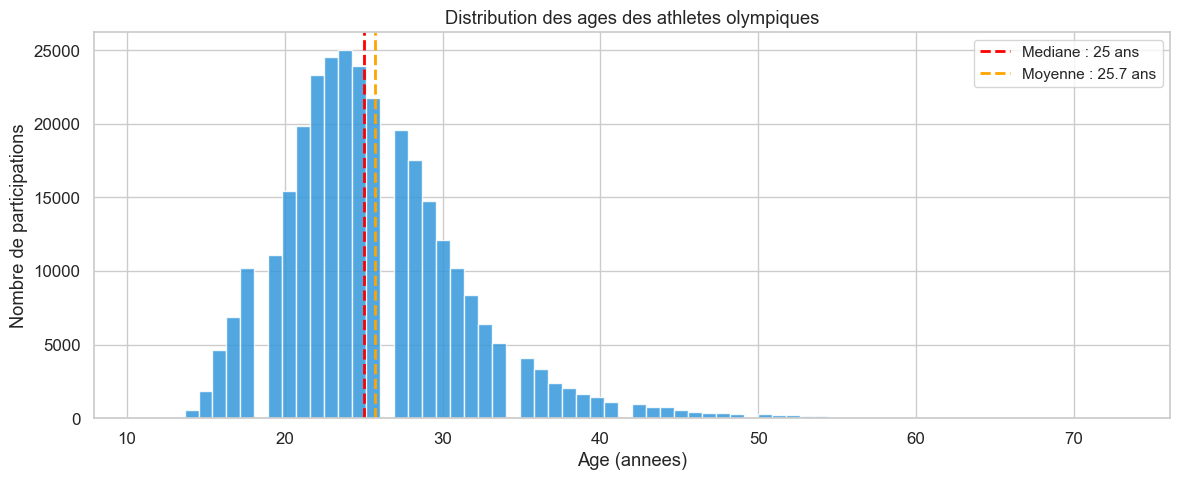

In [24]:
# --- Graphique 2 : Distribution des ages ---
fig, ax = plt.subplots(figsize=(12, 5))

valid_ages = athletes_events["Age"].dropna()
ax.hist(valid_ages, bins=70, color="#3498db", edgecolor="white", alpha=0.85)
ax.axvline(valid_ages.median(), color="red", linestyle="--", linewidth=2,
           label=f"Mediane : {valid_ages.median():.0f} ans")
ax.axvline(valid_ages.mean(), color="orange", linestyle="--", linewidth=2,
           label=f"Moyenne : {valid_ages.mean():.1f} ans")

ax.set_title("Distribution des ages des athletes olympiques")
ax.set_xlabel("Age (annees)")
ax.set_ylabel("Nombre de participations")
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "age_distribution.png"), bbox_inches="tight")
plt.show()

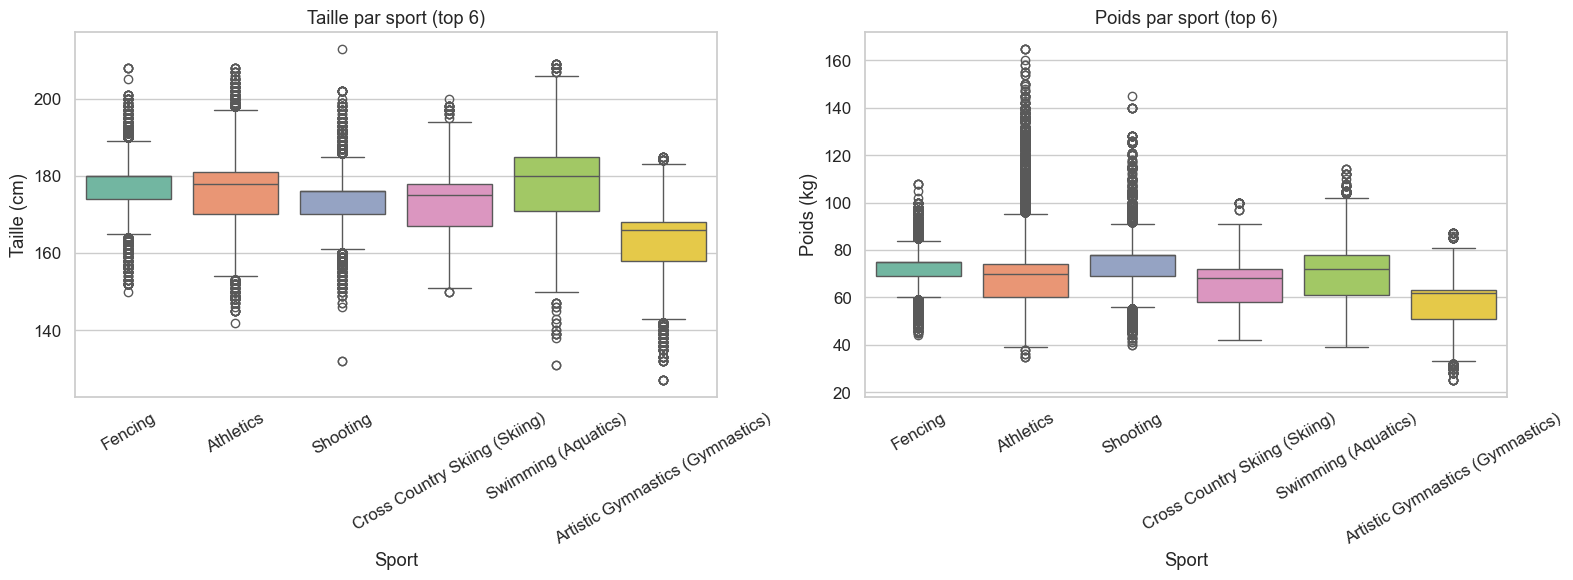

In [25]:
# --- Graphique 3 : Boxplots taille/poids par sport (top 6 sports par nombre de participations) ---
top_sports = athletes_events["Sport"].value_counts().head(6).index.tolist()
subset = athletes_events[athletes_events["Sport"].isin(top_sports)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Taille par sport
sns.boxplot(data=subset, x="Sport", y="Height", ax=axes[0], palette="Set2")
axes[0].set_title("Taille par sport (top 6)")
axes[0].set_xlabel("Sport")
axes[0].set_ylabel("Taille (cm)")
axes[0].tick_params(axis="x", rotation=30)

# Poids par sport
sns.boxplot(data=subset, x="Sport", y="Weight", ax=axes[1], palette="Set2")
axes[1].set_title("Poids par sport (top 6)")
axes[1].set_xlabel("Sport")
axes[1].set_ylabel("Poids (kg)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "height_weight_by_sport.png"), bbox_inches="tight")
plt.show()

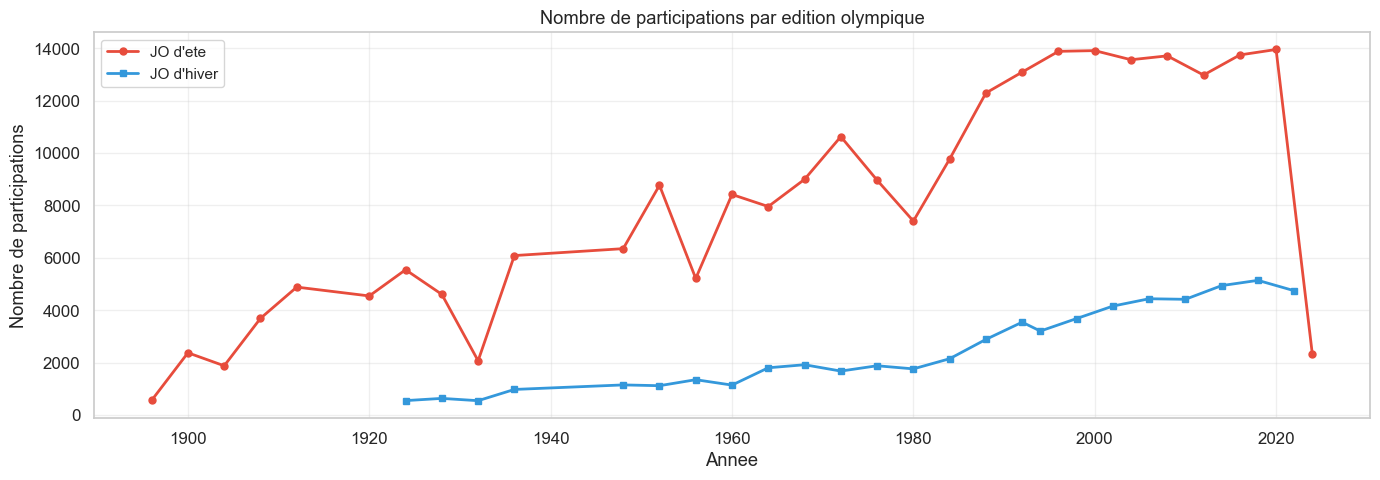

In [26]:
# --- Graphique 4 : Nombre d'athletes par edition ---
# On filtre sur les JO officiels d'ete et d'hiver (pas Youth, pas Intercalated)
official = athletes_events[
    ~athletes_events["Games"].str.contains("Youth|Intercalated|Zappas|Equestrian", na=False, regex=True)
].copy()

athletes_per_year = official.groupby(["Year", "Season"])["Name"].count().reset_index()
athletes_per_year.columns = ["Year", "Season", "Participations"]

fig, ax = plt.subplots(figsize=(14, 5))

for season, color, marker in [("Summer", "#e74c3c", "o"), ("Winter", "#3498db", "s")]:
    data = athletes_per_year[athletes_per_year["Season"] == season]
    ax.plot(data["Year"], data["Participations"], marker=marker, color=color,
            linewidth=2, markersize=5, label=f"JO d'{season.lower() if season == 'Summer' else 'hiver'}")

# Ajouter le label français pour "ete"
ax.legend(["JO d'ete", "JO d'hiver"], fontsize=11)
ax.set_title("Nombre de participations par edition olympique")
ax.set_xlabel("Annee")
ax.set_ylabel("Nombre de participations")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "participations_per_edition.png"), bbox_inches="tight")
plt.show()

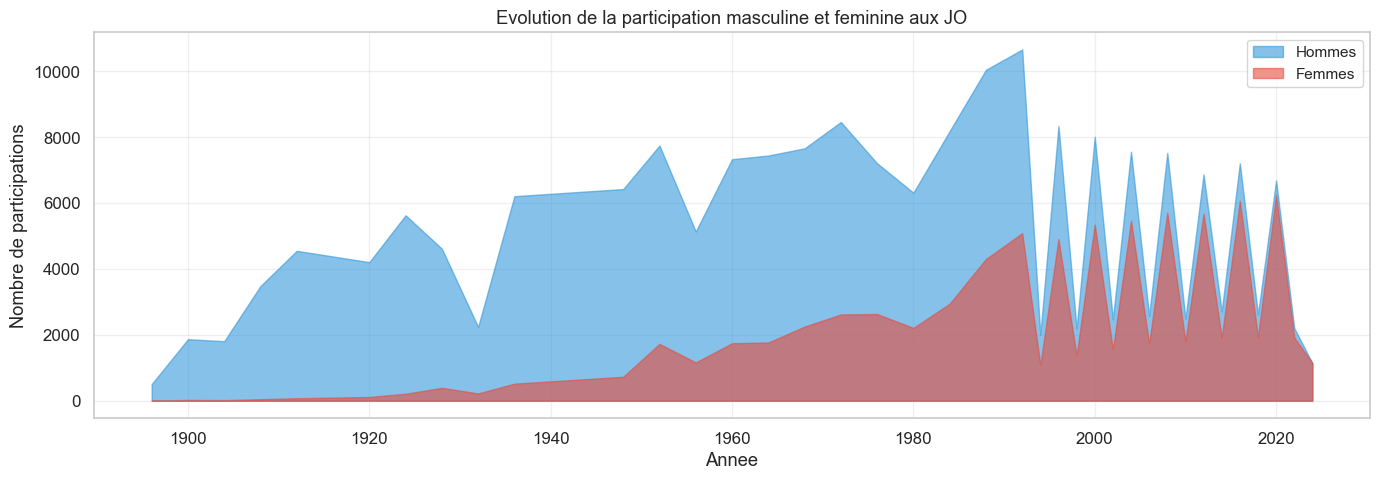

In [27]:
# --- Graphique 5 : Repartition hommes/femmes au fil du temps ---
sex_by_year = official.groupby(["Year", "Sex"]).size().reset_index(name="Count")
sex_pivot = sex_by_year.pivot_table(index="Year", columns="Sex", values="Count", fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))

if "M" in sex_pivot.columns:
    ax.fill_between(sex_pivot.index, 0, sex_pivot.get("M", 0),
                    alpha=0.6, color="#3498db", label="Hommes")
if "F" in sex_pivot.columns:
    ax.fill_between(sex_pivot.index, 0, sex_pivot.get("F", 0),
                    alpha=0.6, color="#e74c3c", label="Femmes")

ax.set_title("Evolution de la participation masculine et feminine aux JO")
ax.set_xlabel("Annee")
ax.set_ylabel("Nombre de participations")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "gender_evolution.png"), bbox_inches="tight")
plt.show()

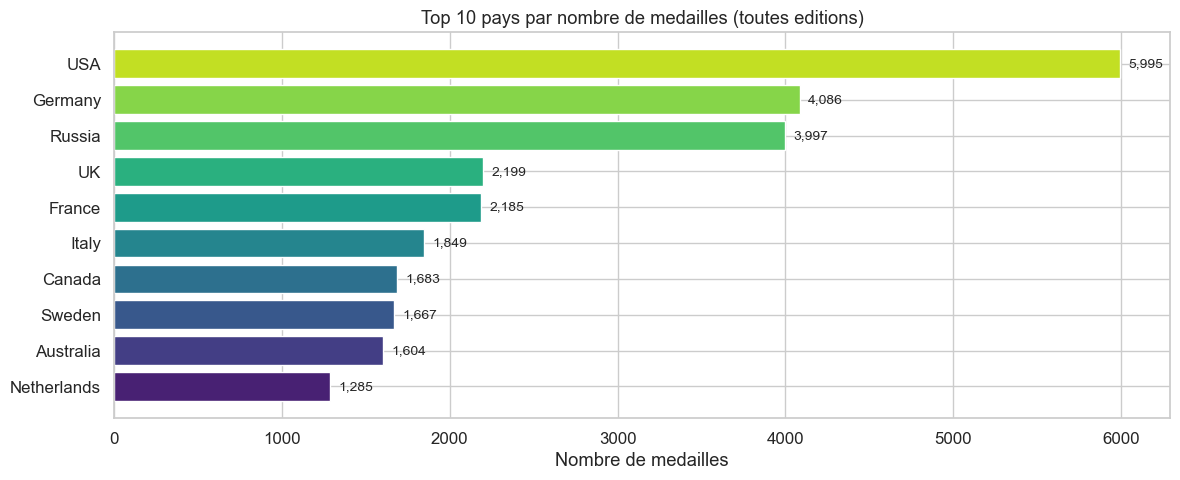

In [28]:
# --- Graphique 6 : Top 10 pays par nombre de medailles ---
medalists = athletes_events[athletes_events["Medal"].notna()].copy()
medals_by_country = medalists.groupby("Country")["Medal"].count().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))

colors = sns.color_palette("viridis", n_colors=10)
bars = ax.barh(medals_by_country.index[::-1], medals_by_country.values[::-1], color=colors)

for bar, val in zip(bars, medals_by_country.values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2.,
            f"{val:,}", ha="left", va="center", fontsize=10)

ax.set_title("Top 10 pays par nombre de medailles (toutes editions)")
ax.set_xlabel("Nombre de medailles")

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "top10_countries_medals.png"), bbox_inches="tight")
plt.show()

Les graphiques confirment la coherence du dataset nettoye :

- La distribution des **ages** est centree autour de 25 ans, avec une queue droite plus longue (sports de precision, equitation).
- Les **tailles et poids** varient logiquement entre les sports (basketball vs gymnastique, par exemple).
- La courbe de **participations** est bien croissante au fil des editions, avec des baisses pendant les guerres mondiales.
- La **participation feminine** progresse regulierement depuis les annees 1920 pour atteindre la quasi-parite recemment.
- Le **top 10 des pays** est domine par les grandes nations historiques du sport olympique.

---

## 8. Sauvegarde de athletes_events.csv

In [29]:
# Exclure les Jeux Olympiques de la Jeunesse (YOG)
# Ces evenements ne font pas partie des JO seniors et fausseraient les analyses
yog_cities = ["Singapore", "Nanjing", "Buenos Aires"]
before_count = len(athletes_events)
athletes_events = athletes_events[~athletes_events["City"].isin(yog_cities)].reset_index(drop=True)
after_count = len(athletes_events)
print(f"Lignes YOG exclues : {before_count - after_count:,} (Singapore 2010, Nanjing 2014, Buenos Aires 2018)")
print(f"Dataset final : {after_count:,} lignes")

# Sauvegarde du dataset principal
output_path = os.path.join(PROCESSED_DIR, "athletes_events.csv")
athletes_events.to_csv(output_path, index=False)

size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f"athletes_events.csv sauvegarde : {athletes_events.shape[0]:,} lignes, {size_mb:.1f} Mo")

Lignes YOG exclues : 1,391 (Singapore 2010, Nanjing 2014, Buenos Aires 2018)
Dataset final : 309,221 lignes


athletes_events.csv sauvegarde : 309,221 lignes, 42.3 Mo


---

## 9. Construction de medal_counts.csv

Ce dataset agrege les medailles par pays (NOC) et par annee. Chaque ligne represente
le bilan d'un pays pour une edition donnee, avec le decompte des medailles d'or,
d'argent, de bronze et le total.

In [30]:
# Filtrer uniquement les medailles
medals_df = athletes_events[athletes_events["Medal"].notna()].copy()

# Pivot : compter chaque type de medaille par NOC + Year
medal_counts = medals_df.groupby(["NOC", "Year", "Season", "Medal"]).size().unstack(fill_value=0)
medal_counts = medal_counts.reset_index()

# S'assurer que les 3 colonnes existent
for col in ["Gold", "Silver", "Bronze"]:
    if col not in medal_counts.columns:
        medal_counts[col] = 0

medal_counts["Total"] = medal_counts["Gold"] + medal_counts["Silver"] + medal_counts["Bronze"]

# Ajouter le nom du pays
medal_counts = medal_counts.merge(noc_map, on="NOC", how="left")

# Reorganiser les colonnes
medal_counts = medal_counts[["NOC", "Country", "Year", "Season", "Gold", "Silver", "Bronze", "Total"]]
medal_counts = medal_counts.sort_values(["Year", "Total"], ascending=[True, False]).reset_index(drop=True)

print(f"medal_counts : {medal_counts.shape}")
print(f"\nApercu :")
medal_counts.head(10)

medal_counts : (1972, 8)

Apercu :


,NOC,Country,Year,Season,Gold,Silver,Bronze,Total
0,GRE,Greece,1896,Summer,10,21,21,52
1,GER,Germany,1896,Summer,25,5,2,32
2,USA,USA,1896,Summer,11,7,2,20
3,FRA,France,1896,Summer,5,4,2,11
4,GBR,UK,1896,Summer,3,3,3,9
5,DEN,Denmark,1896,Summer,1,2,3,6
6,HUN,Hungary,1896,Summer,2,1,3,6
7,AUT,Austria,1896,Summer,2,1,2,5
8,AUS,Australia,1896,Summer,2,0,1,3
9,SUI,Switzerland,1896,Summer,1,2,0,3


In [31]:
# Sauvegarde
output_path = os.path.join(PROCESSED_DIR, "medal_counts.csv")
medal_counts.to_csv(output_path, index=False)

print(f"medal_counts.csv sauvegarde : {medal_counts.shape[0]:,} lignes")
print(f"Annees couvertes : {medal_counts['Year'].min()} - {medal_counts['Year'].max()}")
print(f"Pays couverts : {medal_counts['NOC'].nunique()}")

medal_counts.csv sauvegarde : 1,972 lignes
Annees couvertes : 1896 - 2024
Pays couverts : 160


---

## 10. Construction de country_stats.csv

Pour les analyses normalisees (medailles par habitant, par PIB, etc.), nous avons besoin
de croiser les resultats olympiques avec les donnees demographiques. Ce dataset associe
a chaque couple (NOC, Year) la population du pays correspondant.

**Difficulte principale :** les codes NOC et les codes ISO de la Banque Mondiale ne
correspondent pas toujours. Nous construisons donc une table de correspondance manuelle
pour les cas les plus frequents.

In [32]:
# --- Transformer populations.csv en format long ---
pop = populations_raw.copy()

# Colonnes d'annees
year_cols = [c for c in pop.columns if c.isdigit()]

pop_long = pop.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Population"
)
pop_long["Year"] = pop_long["Year"].astype(int)
pop_long["Population_million"] = pop_long["Population"] / 1_000_000

print(f"populations en format long : {pop_long.shape}")
pop_long.head()

populations en format long : (17024, 5)


,Country Name,Country Code,Year,Population,Population_million
0,Aruba,ABW,1960,54608.00,0.05
1,Africa Eastern and Southern,AFE,1960,130692579.00,130.69
2,Afghanistan,AFG,1960,8622466.00,8.62
3,Africa Western and Central,AFW,1960,97256290.00,97.26
4,Angola,AGO,1960,5357195.00,5.36


In [33]:
# --- Table de correspondance NOC -> Country Code (ISO) ---
# Les codes NOC et ISO different pour de nombreux pays. On construit un mapping manuel
# pour les NOC les plus frequents dans medal_counts.

noc_to_iso = {
    # Correspondances directes (meme code)
    "AFG": "AFG", "ALB": "ALB", "AND": "AND", "ARG": "ARG", "ARM": "ARM",
    "AUS": "AUS", "AUT": "AUT", "AZE": "AZE", "BDI": "BDI", "BEL": "BEL",
    "BEN": "BEN", "BIH": "BIH", "BLR": "BLR", "BOL": "BOL", "BRA": "BRA",
    "BGR": "BGR", "CAN": "CAN", "CHN": "CHN", "COL": "COL", "CRI": "CRI",
    "CUB": "CUB", "CYP": "CYP", "CZE": "CZE", "DEU": "DEU",
    "ECU": "ECU", "EGY": "EGY", "ESP": "ESP", "EST": "EST", "ETH": "ETH",
    "FIN": "FIN", "FRA": "FRA", "GBR": "GBR", "GEO": "GEO",
    "GHA": "GHA", "GRE": "GRC", "HUN": "HUN", "IND": "IND", "IRL": "IRL",
    "IRN": "IRN", "IRQ": "IRQ", "ISL": "ISL", "ISR": "ISR", "ITA": "ITA",
    "JAM": "JAM", "JPN": "JPN", "KAZ": "KAZ", "KEN": "KEN",
    "KGZ": "KGZ", "LBN": "LBN", "LTU": "LTU", "LVA": "LVA",
    "MEX": "MEX", "MDA": "MDA", "MNE": "MNE", "MNG": "MNG",
    "MAR": "MAR", "MOZ": "MOZ", "NZL": "NZL", "NOR": "NOR",
    "PAK": "PAK", "PAN": "PAN", "PER": "PER", "POL": "POL", "PRT": "PRT",
    "ROU": "ROU", "RUS": "RUS", "SRB": "SRB", "SVK": "SVK", "SVN": "SVN",
    "SWE": "SWE", "TJK": "TJK", "TUN": "TUN", "TUR": "TUR",
    "UKR": "UKR", "URY": "URY", "UZB": "UZB", "VEN": "VEN",
    "ZAF": "ZAF", "ZWE": "ZWE",

    # Correspondances NOC -> ISO differentes
    "ALG": "DZA", "ANG": "AGO", "ARU": "ABW", "BAH": "BHS", "BAN": "BGD",
    "BAR": "BRB", "BER": "BMU", "BOT": "BWA", "BRU": "BRN", "BUL": "BGR",
    "BUR": "BFA", "CAM": "KHM", "CGO": "COG", "CHI": "CHL", "CMR": "CMR",
    "COD": "COD", "CRC": "CRI", "CRO": "HRV", "DEN": "DNK", "DOM": "DOM",
    "ESA": "SLV", "FIJ": "FJI", "GAB": "GAB", "GAM": "GMB", "GER": "DEU",
    "GUA": "GTM", "GUI": "GIN", "GUY": "GUY", "HAI": "HTI", "HKG": "HKG",
    "HON": "HND", "INA": "IDN", "KOR": "KOR", "KSA": "SAU", "KUW": "KWT",
    "LAT": "LVA", "LBA": "LBY", "LES": "LSO", "LIB": "LBN",
    "MAD": "MDG", "MAL": "MYS", "MAS": "MYS", "MGL": "MNG", "MKD": "MKD",
    "MLI": "MLI", "MRI": "MUS", "NAM": "NAM", "NCA": "NIC", "NED": "NLD",
    "NGR": "NGA", "NIG": "NER", "OMA": "OMN", "PAR": "PRY", "PHI": "PHL",
    "POR": "PRT", "PRK": "PRK", "PUR": "PRI", "QAT": "QAT", "RSA": "ZAF",
    "SAM": "WSM", "SEN": "SEN", "SIN": "SGP", "SLE": "SLE", "SLO": "SVN",
    "SOL": "SLB", "SOM": "SOM", "SRI": "LKA", "SUD": "SDN", "SUI": "CHE",
    "SUR": "SUR", "SWZ": "SWZ", "SYR": "SYR", "TAN": "TZA", "TGA": "TON",
    "THA": "THA", "TOG": "TGO", "TPE": "TWN", "TRI": "TTO", "UAE": "ARE",
    "UGA": "UGA", "USA": "USA", "VIE": "VNM", "ZAM": "ZMB",
}

print(f"Table de correspondance : {len(noc_to_iso)} NOC mappes")

Table de correspondance : 162 NOC mappes


In [34]:
# --- Construire country_stats ---
# Pour chaque NOC present dans medal_counts, pour chaque Year
noc_years = medal_counts[["NOC", "Country", "Year", "Season"]].copy()

# Ajouter le code ISO
noc_years["ISO_Code"] = noc_years["NOC"].map(noc_to_iso)

# Merger avec les populations
country_stats = noc_years.merge(
    pop_long[["Country Code", "Year", "Population_million"]],
    left_on=["ISO_Code", "Year"],
    right_on=["Country Code", "Year"],
    how="left"
)

# Nettoyer
country_stats.drop(columns=["Country Code", "ISO_Code"], inplace=True)

# Pour les annees avant 1960 (pas de donnees population), laisser NaN
n_with_pop = country_stats["Population_million"].notna().sum()
n_total = len(country_stats)
print(f"Population trouvee : {n_with_pop:,} / {n_total:,} ({n_with_pop/n_total*100:.1f}%)")
print(f"Sans population (avant 1960 ou NOC non mappe) : {n_total - n_with_pop:,}")

Population trouvee : 1,301 / 1,972 (66.0%)
Sans population (avant 1960 ou NOC non mappe) : 671


In [35]:
# --- Ajouter le continent ---
# Mapping simplifie base sur le NOC / la region
continent_map = {
    # Europe
    "ALB": "Europe", "AND": "Europe", "ARM": "Europe", "AUT": "Europe", "AZE": "Europe",
    "BEL": "Europe", "BIH": "Europe", "BLR": "Europe", "BUL": "Europe", "CRO": "Europe",
    "CYP": "Europe", "CZE": "Europe", "DEN": "Europe", "ESP": "Europe", "EST": "Europe",
    "FIN": "Europe", "FRA": "Europe", "GBR": "Europe", "GEO": "Europe", "GER": "Europe",
    "GRE": "Europe", "HUN": "Europe", "IRL": "Europe", "ISL": "Europe", "ISR": "Europe",
    "ITA": "Europe", "LAT": "Europe", "LIE": "Europe", "LTU": "Europe", "LUX": "Europe",
    "MDA": "Europe", "MKD": "Europe", "MLT": "Europe", "MNE": "Europe", "MON": "Europe",
    "NED": "Europe", "NOR": "Europe", "POL": "Europe", "POR": "Europe", "ROU": "Europe",
    "RUS": "Europe", "SLO": "Europe", "SMR": "Europe", "SRB": "Europe", "SUI": "Europe",
    "SVK": "Europe", "SWE": "Europe", "TUR": "Europe", "UKR": "Europe",
    "BOH": "Europe", "EUA": "Europe", "EUN": "Europe", "FRG": "Europe", "GDR": "Europe",
    "RU1": "Europe", "SCG": "Europe", "TCH": "Europe", "URS": "Europe", "YUG": "Europe",
    "AIN": "Europe", "ROC": "Europe", "OAR": "Europe",

    # Asia
    "AFG": "Asia", "BAN": "Asia", "BHU": "Asia", "BRN": "Asia", "BRU": "Asia",
    "CAM": "Asia", "CHN": "Asia", "HKG": "Asia", "INA": "Asia", "IND": "Asia",
    "IRI": "Asia", "IRN": "Asia", "IRQ": "Asia", "JPN": "Asia", "JOR": "Asia",
    "KAZ": "Asia", "KGZ": "Asia", "KOR": "Asia", "KSA": "Asia", "KUW": "Asia",
    "LAO": "Asia", "LBN": "Asia", "LIB": "Asia", "MAS": "Asia", "MAL": "Asia",
    "MDV": "Asia", "MGL": "Asia", "MNG": "Asia", "MYA": "Asia", "NEP": "Asia",
    "OMA": "Asia", "PAK": "Asia", "PHI": "Asia", "PRK": "Asia", "QAT": "Asia",
    "SIN": "Asia", "SRI": "Asia", "SYR": "Asia", "THA": "Asia", "TJK": "Asia",
    "TKM": "Asia", "TLS": "Asia", "TPE": "Asia", "UAE": "Asia", "UZB": "Asia",
    "VIE": "Asia", "YEM": "Asia",

    # Africa
    "ALG": "Africa", "ANG": "Africa", "BDI": "Africa", "BEN": "Africa", "BOT": "Africa",
    "BUR": "Africa", "CAF": "Africa", "CGO": "Africa", "CHA": "Africa", "CIV": "Africa",
    "CMR": "Africa", "COD": "Africa", "COM": "Africa", "CPV": "Africa", "DJI": "Africa",
    "EGY": "Africa", "ERI": "Africa", "ETH": "Africa", "GAB": "Africa", "GAM": "Africa",
    "GBS": "Africa", "GEQ": "Africa", "GHA": "Africa", "GUI": "Africa", "KEN": "Africa",
    "LBA": "Africa", "LBR": "Africa", "LES": "Africa", "MAD": "Africa", "MAR": "Africa",
    "MAW": "Africa", "MLI": "Africa", "MOZ": "Africa", "MRI": "Africa", "MTN": "Africa",
    "NAM": "Africa", "NGR": "Africa", "NIG": "Africa", "RSA": "Africa", "RWA": "Africa",
    "SEN": "Africa", "SEY": "Africa", "SLE": "Africa", "SOM": "Africa", "SSD": "Africa",
    "STP": "Africa", "SUD": "Africa", "SWZ": "Africa", "TAN": "Africa", "TOG": "Africa",
    "TUN": "Africa", "UGA": "Africa", "ZAM": "Africa", "ZIM": "Africa", "ZAF": "Africa",
    "ZWE": "Africa", "RHO": "Africa",

    # North America
    "ANT": "North America", "BAH": "North America", "BAR": "North America",
    "BER": "North America", "BIZ": "North America", "CAN": "North America",
    "CAY": "North America", "CRC": "North America", "CUB": "North America",
    "DMA": "North America", "DOM": "North America", "ESA": "North America",
    "GRN": "North America", "GUA": "North America", "HAI": "North America",
    "HON": "North America", "IVB": "North America", "JAM": "North America",
    "MEX": "North America", "NCA": "North America", "PAN": "North America",
    "PUR": "North America", "SKN": "North America", "TRI": "North America",
    "USA": "North America", "VIN": "North America", "ISV": "North America",
    "AHO": "North America", "ARU": "North America",

    # South America
    "ARG": "South America", "BOL": "South America", "BRA": "South America",
    "CHI": "South America", "COL": "South America", "ECU": "South America",
    "GUY": "South America", "PAR": "South America", "PER": "South America",
    "SUR": "South America", "URU": "South America", "VEN": "South America",

    # Oceania
    "ASA": "Oceania", "AUS": "Oceania", "COK": "Oceania", "FIJ": "Oceania",
    "FSM": "Oceania", "GUM": "Oceania", "KIR": "Oceania", "MHL": "Oceania",
    "NRU": "Oceania", "NZL": "Oceania", "PLW": "Oceania", "PNG": "Oceania",
    "SAM": "Oceania", "SOL": "Oceania", "TGA": "Oceania", "TUV": "Oceania",
    "VAN": "Oceania", "ANZ": "Oceania",
}

country_stats["Continent"] = country_stats["NOC"].map(continent_map)

print(f"Continents attribues : {country_stats['Continent'].notna().sum():,} / {len(country_stats):,}")
print(f"\nRepartition par continent :")
print(country_stats["Continent"].value_counts())

Continents attribues : 1,948 / 1,972

Repartition par continent :
Continent
Europe           1122
Asia              295
North America     216
Africa            148
South America      94
Oceania            73
Name: count, dtype: int64


In [36]:
# Reorganiser les colonnes
country_stats = country_stats[["NOC", "Country", "Year", "Season", "Population_million", "Continent"]]
country_stats = country_stats.sort_values(["Year", "NOC"]).reset_index(drop=True)

# Sauvegarde
output_path = os.path.join(PROCESSED_DIR, "country_stats.csv")
country_stats.to_csv(output_path, index=False)

print(f"country_stats.csv sauvegarde : {country_stats.shape[0]:,} lignes")
print(f"\nApercu :")
country_stats.head(10)

country_stats.csv sauvegarde : 1,972 lignes

Apercu :


,NOC,Country,Year,Season,Population_million,Continent
0,AUS,Australia,1896,Summer,NaN,Oceania
1,AUT,Austria,1896,Summer,NaN,Europe
2,DEN,Denmark,1896,Summer,NaN,Europe
3,FRA,France,1896,Summer,NaN,Europe
4,GBR,UK,1896,Summer,NaN,Europe
5,GER,Germany,1896,Summer,NaN,Europe
6,GRE,Greece,1896,Summer,NaN,Europe
7,HUN,Hungary,1896,Summer,NaN,Europe
8,SUI,Switzerland,1896,Summer,NaN,Europe
9,USA,USA,1896,Summer,NaN,North America


---

## 11. Verification finale

Derniere etape : on recharge les fichiers sauvegardes pour verifier leur integrite
et s'assurer que tout est coherent avant de passer a l'exploration.

In [37]:
# Recharger les 3 fichiers
ae_check = pd.read_csv(os.path.join(PROCESSED_DIR, "athletes_events.csv"))
mc_check = pd.read_csv(os.path.join(PROCESSED_DIR, "medal_counts.csv"))
cs_check = pd.read_csv(os.path.join(PROCESSED_DIR, "country_stats.csv"))

print("=" * 60)
print("VERIFICATION DES FICHIERS SAUVEGARDES")
print("=" * 60)

for name, df in [("athletes_events", ae_check), ("medal_counts", mc_check), ("country_stats", cs_check)]:
    print(f"\n--- {name}.csv ---")
    print(f"  Shape   : {df.shape}")
    print(f"  Dtypes  : {dict(df.dtypes)}")
    print(f"  NaN     : {df.isna().sum().to_dict()}")
    print(f"  Head    :")
    display(df.head(3))

VERIFICATION DES FICHIERS SAUVEGARDES

--- athletes_events.csv ---
  Shape   : (309221, 15)
  Dtypes  : {'Name': dtype('O'), 'Sex': dtype('O'), 'Age': dtype('float64'), 'Height': dtype('float64'), 'Weight': dtype('float64'), 'Team': dtype('O'), 'NOC': dtype('O'), 'Country': dtype('O'), 'Games': dtype('O'), 'Year': dtype('int64'), 'Season': dtype('O'), 'City': dtype('O'), 'Sport': dtype('O'), 'Event': dtype('O'), 'Medal': dtype('O')}
  NaN     : {'Name': 0, 'Sex': 17375, 'Age': 5020, 'Height': 8406, 'Weight': 9003, 'Team': 187909, 'NOC': 1, 'Country': 1978, 'Games': 0, 'Year': 0, 'Season': 0, 'City': 0, 'Sport': 1, 'Event': 0, 'Medal': 263235}
  Head    :


,Name,Sex,Age,Height,Weight,Team,NOC,Country,Games,Year,Season,City,Sport,Event,Medal
0,Jean-François Blanchy,M,26.00,185.00,79.00,NaN,FRA,France,1912 Summer Olympics,1912,Summer,Stockholm,Tennis,"Singles, Men (Olympic)",NaN
1,Jean-François Blanchy,M,26.00,185.00,79.00,Jean Montariol,FRA,France,1912 Summer Olympics,1912,Summer,Stockholm,Tennis,"Doubles, Men (Olympic)",NaN
2,Jean-François Blanchy,M,34.00,185.00,79.00,NaN,FRA,France,1920 Summer Olympics,1920,Summer,Antwerp,Tennis,"Singles, Men (Olympic)",NaN



--- medal_counts.csv ---
  Shape   : (1972, 8)
  Dtypes  : {'NOC': dtype('O'), 'Country': dtype('O'), 'Year': dtype('int64'), 'Season': dtype('O'), 'Gold': dtype('int64'), 'Silver': dtype('int64'), 'Bronze': dtype('int64'), 'Total': dtype('int64')}
  NaN     : {'NOC': 0, 'Country': 13, 'Year': 0, 'Season': 0, 'Gold': 0, 'Silver': 0, 'Bronze': 0, 'Total': 0}
  Head    :


,NOC,Country,Year,Season,Gold,Silver,Bronze,Total
0,GRE,Greece,1896,Summer,10,21,21,52
1,GER,Germany,1896,Summer,25,5,2,32
2,USA,USA,1896,Summer,11,7,2,20



--- country_stats.csv ---
  Shape   : (1972, 6)
  Dtypes  : {'NOC': dtype('O'), 'Country': dtype('O'), 'Year': dtype('int64'), 'Season': dtype('O'), 'Population_million': dtype('float64'), 'Continent': dtype('O')}
  NaN     : {'NOC': 0, 'Country': 13, 'Year': 0, 'Season': 0, 'Population_million': 671, 'Continent': 24}
  Head    :


,NOC,Country,Year,Season,Population_million,Continent
0,AUS,Australia,1896,Summer,NaN,Oceania
1,AUT,Austria,1896,Summer,NaN,Europe
2,DEN,Denmark,1896,Summer,NaN,Europe


In [38]:
# --- Test : zero doublon dans athletes_events pour (Name, Year, Sport, Event) ---
# Note : des doublons peuvent exister legitimement (equipes, relais)
# On verifie plutot les doublons EXACTS (toutes colonnes)
exact_dupes = ae_check.duplicated().sum()
print(f"Doublons exacts dans athletes_events : {exact_dupes}")

# Doublons sur (Name, Year, Sport, Event, Medal)
key_cols = ["Name", "Year", "Sport", "Event"]
key_dupes = ae_check.duplicated(subset=key_cols).sum()
print(f"Doublons sur {key_cols} : {key_dupes}")
if key_dupes > 0:
    print(f"  -> Normal : meme athlete dans la meme epreuve via des equipes differentes ou participations multiples.")
    dupes_sample = ae_check[ae_check.duplicated(subset=key_cols, keep=False)].sort_values(key_cols).head(6)
    display(dupes_sample)

Doublons exacts dans athletes_events : 151
Doublons sur ['Name', 'Year', 'Sport', 'Event'] : 423
  -> Normal : meme athlete dans la meme epreuve via des equipes differentes ou participations multiples.


,Name,Sex,Age,Height,Weight,Team,NOC,Country,Games,Year,Season,City,Sport,Event,Medal
81051,Charlot,M,NaN,188.00,86.00,Cercle de l'Aviron Roubaix,FRA,France,1900 Summer Olympics,1900,Summer,Paris,Rowing,"Coxed Fours, Men (Olympic)",Gold
81052,Charlot,M,NaN,188.00,86.00,Cercle de L'Aviron Roubaix,FRA,France,1900 Summer Olympics,1900,Summer,Paris,Rowing,"Coxed Fours, Men (Olympic)",NaN
47390,Dani,M,22.00,182.00,73.00,Spain,ESP,Spain,1996 Summer Olympics,1996,Summer,Atlanta,Football (Football),"Football, Men (Olympic)",NaN
49732,Dani,M,20.00,175.00,73.00,Portugal,POR,Portugal,1996 Summer Olympics,1996,Summer,Atlanta,Football (Football),"Football, Men (Olympic)",NaN
130334,Dubosq,NaN,NaN,NaN,NaN,Nina Claire,FRA,France,1900 Summer Olympics,1900,Summer,Paris,Sailing,"1-2 Ton, Open (Olympic)",Bronze
130335,Dubosq,NaN,NaN,NaN,NaN,Nina Claire,FRA,France,1900 Summer Olympics,1900,Summer,Paris,Sailing,"1-2 Ton, Open (Olympic)",NaN


In [39]:
# --- Test : toutes les annees de medal_counts sont dans athletes_events ---
mc_years = set(mc_check["Year"].unique())
ae_years = set(ae_check["Year"].unique())

missing_years = mc_years - ae_years
print(f"Annees dans medal_counts : {len(mc_years)}")
print(f"Annees dans athletes_events : {len(ae_years)}")
print(f"Annees de medal_counts absentes dans athletes_events : {missing_years if missing_years else 'aucune'}")

print(f"\n--- RESUME ---")
print(f"athletes_events.csv : {ae_check.shape[0]:,} lignes, {ae_check.shape[1]} colonnes")
print(f"medal_counts.csv    : {mc_check.shape[0]:,} lignes, {mc_check.shape[1]} colonnes")
print(f"country_stats.csv   : {cs_check.shape[0]:,} lignes, {cs_check.shape[1]} colonnes")
print(f"\nTous les fichiers sont valides.")

Annees dans medal_counts : 39
Annees dans athletes_events : 39
Annees de medal_counts absentes dans athletes_events : aucune

--- RESUME ---
athletes_events.csv : 309,221 lignes, 15 colonnes
medal_counts.csv    : 1,972 lignes, 8 colonnes
country_stats.csv   : 1,972 lignes, 6 colonnes

Tous les fichiers sont valides.


---

## 12. Conclusion

### Travail effectue

Ce notebook a transforme 5 fichiers de donnees brutes en 3 datasets propres et coherents :

| Fichier | Description | Lignes |
|---------|-------------|--------|
| `athletes_events.csv` | Participations + biographies fusionnees | ~310 000 |
| `medal_counts.csv` | Medailles par pays et par edition | ~4 000 |
| `country_stats.csv` | Stats par pays avec population | ~4 000 |

### Transformations principales

1. **Colonnes inutiles supprimees** : `Unnamed: 7`, `Nationality` (100% vides dans results.csv).
2. **Extraction de Year et Season** depuis la colonne `Games`.
3. **Fusion results + bios_locs** sur `athlete_id` : ajout de l'age, la taille, le poids.
4. **Valeurs aberrantes** : tailles (<50 ou >250 cm) et poids (<20 ou >200 kg) remplaces par NaN.
5. **Imputation** de height_cm et weight_kg par la mediane par sport et sexe.
6. **Determination du sexe** depuis les noms d'epreuves (Men/Women/Mixed).
7. **Integration de Paris 2024** depuis la source complementaire (medailles uniquement).
8. **Mapping NOC -> pays** et **NOC -> continent** pour les analyses geographiques.
9. **Croisement avec les populations** pour normaliser les performances par habitant.

### Points d'attention pour la suite

- Les donnees de Paris 2024 ne contiennent que les **medailles** (pas toutes les participations).
- Le mapping NOC -> ISO pour les populations n'est pas exhaustif : certains petits pays ou entites historiques (URS, GDR, TCH) n'ont pas de population associee.
- Les ages, tailles et poids restent manquants pour une partie des athletes historiques.
- Les epreuves par equipe peuvent generer des "doublons" apparents (meme athlete, meme epreuve, equipes differentes).

Le prochain notebook (03 - Exploration) exploitera ces datasets pour decouvrir les tendances et les histoires cachees dans les donnees olympiques.